<a href="https://colab.research.google.com/github/nicolas-sds/MVP-ADBP/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Nícolas Santos dos Santos

**Matrícula:** 4052025002633

**Dataset:** [Steam Store Games](https://www.kaggle.com/datasets/nikdavis/steam-store-games)

## Definição do Problema e Objetivos

O ecossistema da Steam já ultrapassa a marca de **50.000** títulos disponíveis para rodar em computadores com diferentes sistemas, configurando um ambiente de hipercompetição e alta saturação de conteúdos. Nesse contexto, este projeto investiga o problema da descoberta de jogos, analisando sob duas perspectivas complementares: a de desenvolvedores e investidores, focados em visibilidade e retorno de capital investido, e a de gamers, orientados por relevância, personalização e qualidade da experiência.

## Hipóteses do Problema

As hipóteses traçadas são as seguintes:

1.  **Qualidade vs. Preço:** Existe uma correlação positiva entre o preço do título e sua taxa de aprovação, sugerindo que o investimento se traduz em qualidade percebida.
2.  **Nicho de Mercado:** Gêneros com menor volume de títulos apresentam densidade de avaliações positivas superior a gêneros saturados.
3.  **Efeito de Rede:** A presença de funcionalidades e modos de jogo 'Multiplayer' está associada a um volume significativamente maior de reviews e estimativa de proprietários.
4.  **Maturação:** Jogos com maior tempo de mercado acumulam um volume maior de avaliações, funcionando como prova social para novos usuários.

## Tipo de Problema

Este é um problema de Análise Exploratória de Dados e Regressão. O objetivo é investigar como as características de um jogo (preço, gênero, tempo de mercado, suporte a multiplayer) influenciam variáveis contínuas de sucesso, como a taxa de aprovação e o volume de usuários.

## Seleção de Dados

A fonte de dados principal que compõe o estudo é o arquivo [`steam.csv`](https://raw.githubusercontent.com/nicolas-sds/MVP-ADBP/refs/heads/main/dataset/steam.csv), podendo ser utilizado outros arquivos complementares para enriquecer e complementar a análise.

## Atributos do Dataset

No dataset trabalhado ([`steam.csv`](https://raw.githubusercontent.com/nicolas-sds/MVP-ADBP/refs/heads/main/dataset/steam.csv)) encontramos pouco mais de 27 mil amostras, abaixo estão relacionados os atributos encontrados.

| Atributo | Tipo de dado | Descrição |
| :--- | :--- | :--- |
| **appid** | INT | Identificador único do jogo na plataforma Steam. |
| **name** | TEXT | Nome oficial do título. |
| **release_date** | DATE | Data em que o jogo foi lançado. |
| **english** | BINARY | Indica se o jogo possui suporte ao idioma Inglês (1-Sim, 0-Não). |
| **developer** | TEXT | Empresa responsável pelo desenvolvimento. |
| **publisher** | TEXT | Empresa responsável pela publicação. |
| **platforms** | TEXT | Sistemas operacionais suportados (windows, mac, linux). |
| **categories** | TEXT | Funcionalidades do jogo (ex: Multi-player, Single-player). |
| **genres** | TEXT | Gêneros principais associados ao título. |
| **positive_ratings**| INT | Quantidade de avaliações positivas recebidas. |
| **negative_ratings**| INT | Quantidade de avaliações negativas recebidas. |
| **average_playtime**| INT | Média de tempo jogado em minutos por usuário. |
| **owners** | TEXT | Faixa estimada de proprietários. |
| **price** | FLOAT | Preço de venda em USD. |

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset utilizado.

In [261]:
# ====================================
#  import das bibliotecas necessárias
# ====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [262]:
# ====================================
#    Configurações iniciais de visualização
# ====================================

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [263]:
# ====================================
#      Carregamento do dataset
# ====================================

# URL direta do dataset no GITHUB
url = "https://raw.githubusercontent.com/nicolas-sds/MVP-ADBP/refs/heads/main/dataset/steam.csv"
arquivo = url.split("/")[-1]

# Carga do dataset para um  com tratamento
try:
    df = pd.read_csv(url)
    print(f"Arquivo {arquivo} carregado com sucesso!")
except Exception as e:
    print(f"Erro ao carregar o dataset: {e}")

Arquivo steam.csv carregado com sucesso!


In [264]:
# Primeiras linhas do dataframe
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Iris, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Iris possui 150 instâncias (observações), com 50 instâncias para cada uma das três espécies. As quatro características de medição são de tipo numérico (float), enquanto o atributo 'species' é categórico.

In [265]:
# ====================================
#    Apresentação geral dos dados 
# ====================================

print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 27075

Tipos de dados por coluna:
<class 'pandas.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  str    
 2   release_date      27075 non-null  str    
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  str    
 5   publisher         27061 non-null  str    
 6   platforms         27075 non-null  str    
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  str    
 9   genres            27075 non-null  str    
 10  steamspy_tags     27075 non-null  str    
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 

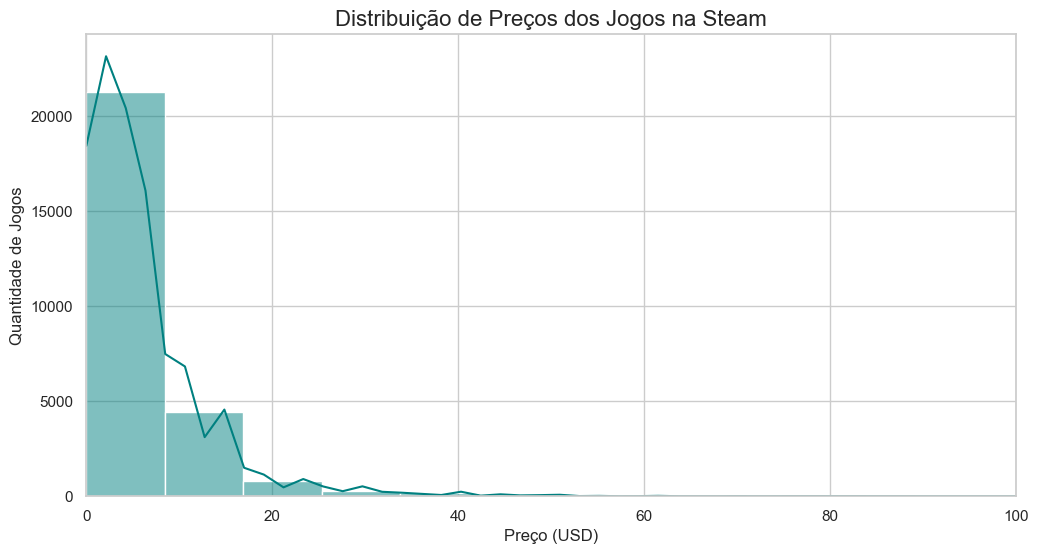

In [266]:
# ====================================
#   Criação de histograma de preços
# ====================================

#  Cria a figura
plt.figure(figsize=(12, 6))

# Criando o Histograma de Preços
ax = sns.histplot(data=df, x='price', bins=50, kde=True, color='teal')

# Customização de títulos e rótulos
plt.title('Distribuição de Preços dos Jogos na Steam', fontsize=16)
plt.xlabel('Preço (USD)', fontsize=12)
plt.ylabel('Quantidade de Jogos', fontsize=12)

# Filtrando jogos até USD 100
plt.xlim(0, 100)
# Exibindo o gráfico
plt.show()

### ❗ Impressões Histograma inicial
O histograma acima revela uma forte concentração de títulos na faixa de preço inferior a $20 (USD). Há um pico acentuado próximo ao zero, indicando um alto volume de jogos gratuitos `Free-to-play` ou de baixo custo `Indie`.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [267]:
# ====================================
#   Início da Estatística Descritiva
# ====================================

# Colunas de interesse
colunas = ['positive_ratings', 'negative_ratings', 'average_playtime', 'achievements', 'price']

# Gerando resumo da base com o comando describe
resumo = df[colunas].describe()

# Adição do cálculo da moda
mode = df[colunas].mode().iloc[0]
resumo.loc['mode'] = mode

# Exibindo o resumo formatado
display(resumo)

,positive_ratings,negative_ratings,average_playtime,achievements,price
count,27075.00,27075.00,27075.00,27075.00,27075.00
mean,1000.56,211.03,149.80,45.25,6.08
std,18988.72,4284.94,1827.04,352.67,7.87
min,0.00,0.00,0.00,0.00,0.00
25%,6.00,2.00,0.00,0.00,1.69
50%,24.00,9.00,0.00,7.00,3.99
75%,126.00,42.00,0.00,23.00,7.19
max,2644404.00,487076.00,190625.00,9821.00,421.99
mode,1.00,0.00,0.00,0.00,3.99


## Análise inicial do resumo

- Preço (`price`): A média de **US$ 6,08** contra uma mediana de **US$ 3,99** revela um mercado fortemente ancorado em preços baixos. Isso indica que a estratégia de entrada da maioria dos desenvolvedores é o baixo custo, tentando mitigar o risco de rejeição.

- Avaliações Positivas (`positive_ratings`): Observa-se um abismo de engajamento onde **50%** dos jogos possuem no máximo 24 avaliações, enquanto o valor mais frequente (`mode`) é de apenas **1** avaliação. Esse dado confirma que a vasta maioria dos títulos falha em gerar tração e visibilidade após o lançamento.

- Avaliações Negativas (`negative_ratings`): A baixa mediana de avaliações negativas (**9**) sugere que o problema central de muitos jogos não é a rejeição explícita (crítica negativa), mas sim a indiferença (falta de qualquer avaliação), o que é um sintoma claro do desafio de descoberta.

- Tempo de Jogo (`average_playtime`): O fato de que **75%** do dataset apresenta 0 minutos de tempo médio de jogo é o indicador mais crítico de saturação. Ele demonstra que uma quantidade massiva de jogos é adquirida ou registrada, mas nunca chega a ser consumida, refletindo a competição de atenção do usuário.

- Conquistas (`achievements`): Com uma moda de 0, percebe-se que o dataset falha em trazer essa informação ou uma grande parcela dos jogos não utiliza mecanismos básicos de retenção e gamificação, o que pode estar correlacionado ao baixo tempo de jogo observado nas métricas anteriores.

### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [268]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

appid              596203.51
english                 0.98
required_age            0.35
achievements           45.25
positive_ratings     1000.56
negative_ratings      211.03
average_playtime      149.80
median_playtime       146.06
price                   6.08
Name: mean, dtype: float64

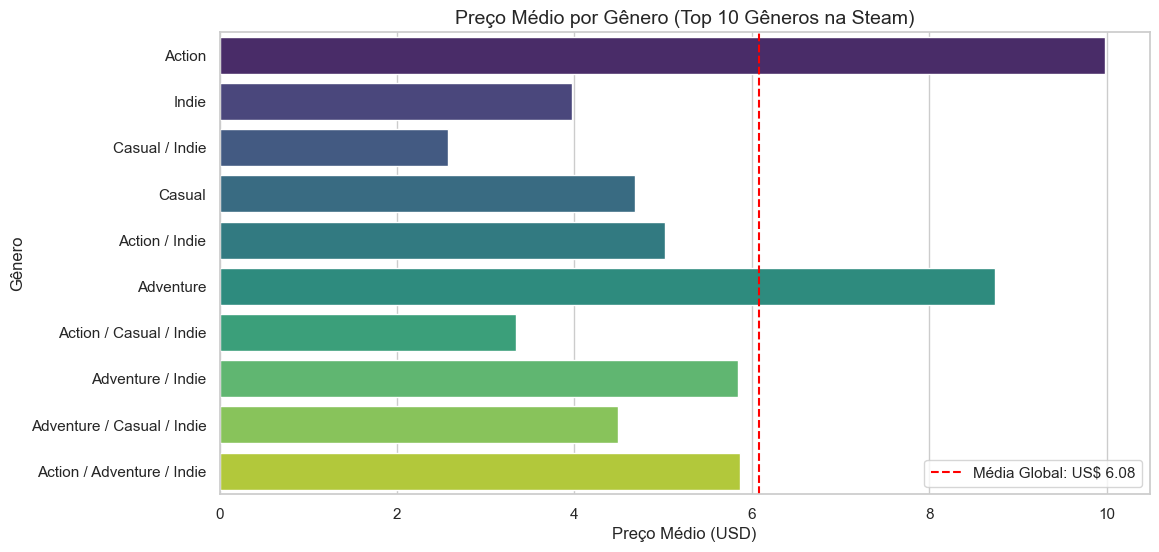

In [269]:
# ====================================
#  Gráfico de preço médio por Gênero
# ====================================

# Selecionando os 10 gêneros mais frequentes para evitar poluição visual
top_genres_original = df['genres'].value_counts().nlargest(10).index
df_plot = df[df['genres'].isin(top_genres_original)].copy()

# Substituição de ; para /
df_plot['genres'] = df_plot['genres'].str.replace(';', ' / ')

plt.figure(figsize=(12, 6))

# Criando o gráfico de barras com a média (estimator=np.mean)
sns.barplot(
    data=df_plot, 
    x='price', 
    y='genres', 
    hue='genres',
    palette='viridis', 
    legend=False,
    errorbar=None
)

# Adicionando uma linha vertical para a Média Global
mean_global = df['price'].mean()
plt.axvline(mean_global, color='red', linestyle='--', label=f'Média Global: US$ {mean_global:.2f}')

plt.title('Preço Médio por Gênero (Top 10 Gêneros na Steam)', fontsize=14)
plt.xlabel('Preço Médio (USD)')
plt.ylabel('Gênero')
plt.legend()
plt.show()

O gráfico acima demonstra que gêneros como `Action` (ação) e `Adventure` (aventura) possuem uma média de preço superior à média global da plataforma (linha vermelha). Isso sugere que títulos nestas categorias conseguem sustentar preços mais altos, possivelmente devido a um custo de produção maior (AAA) ou a um público de nicho mais fiel.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

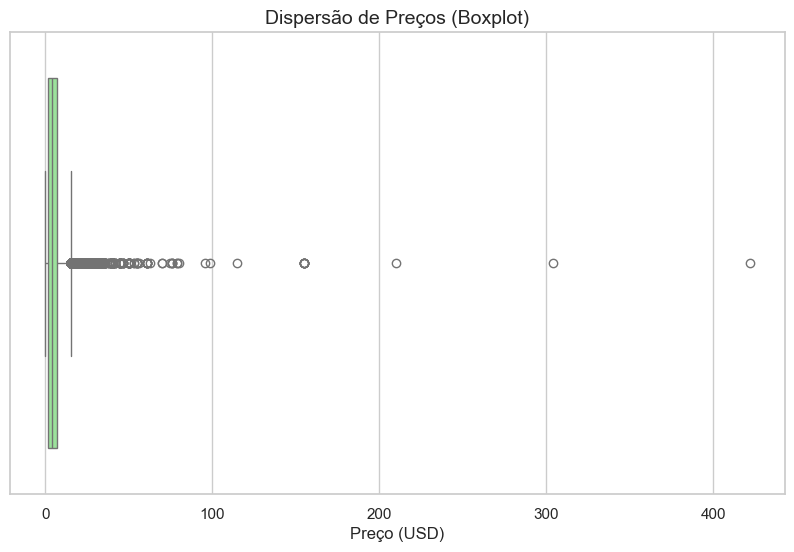

In [270]:
# ====================================
#  Gráfico de desvio padrão de preços
# ====================================

# Calculando o Desvio Padrão isoladamente para as métricas de sucesso
std_metrics = df[['positive_ratings', 'negative_ratings', 'price', 'average_playtime']].std()

# Criando um DataFrame para facilitar a visualização no relatório
df_std = pd.DataFrame(std_metrics, columns=['Desvio Padrão'])

# Visualização da Dispersão: Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'], color='lightgreen')
plt.title('Dispersão de Preços (Boxplot)', fontsize=14)
plt.xlabel('Preço (USD)')
plt.show()

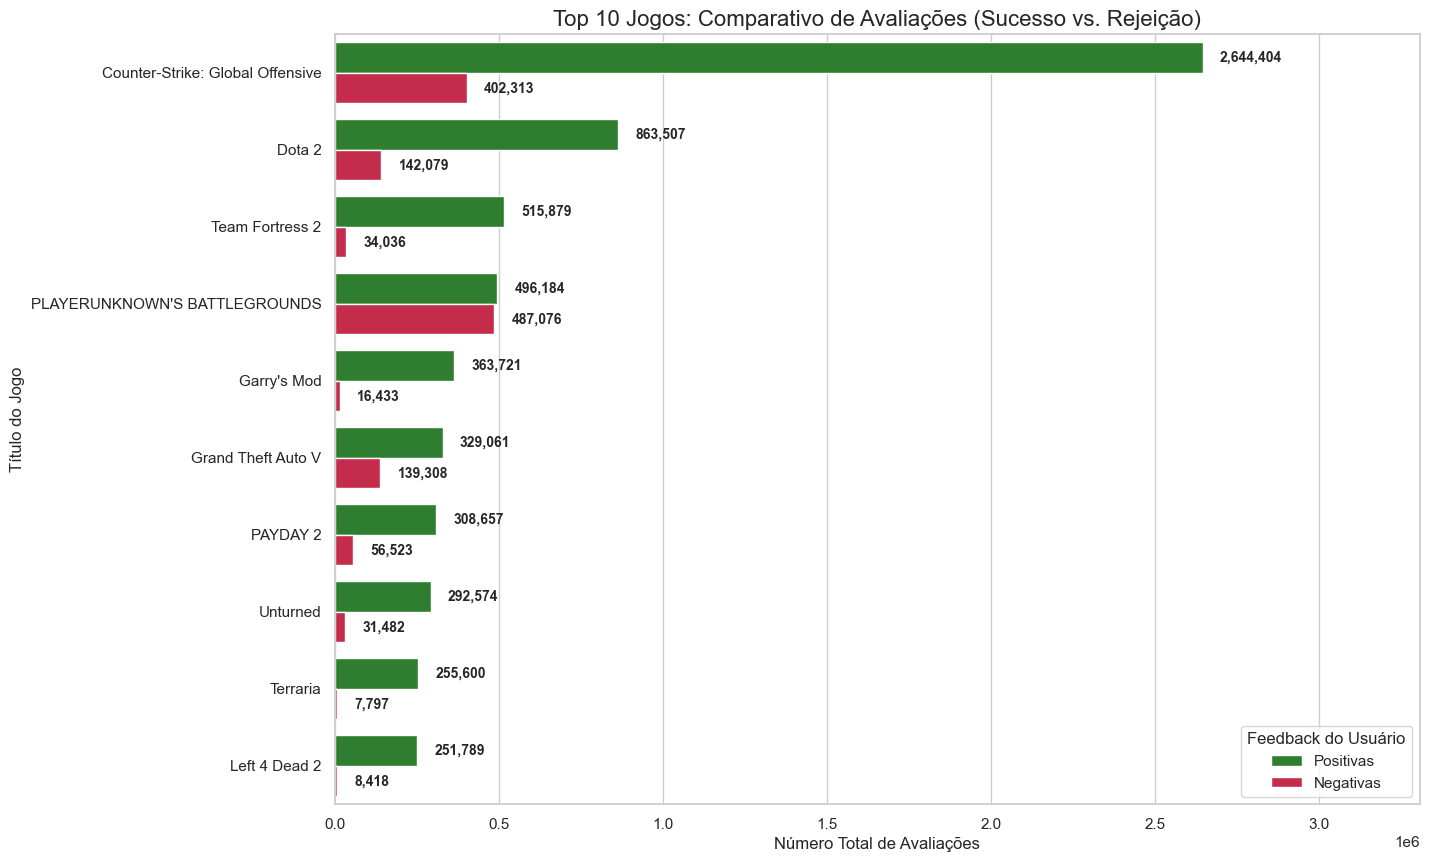

In [271]:
# ==================================================
#   Gráfico de Avaliações Positivas vs. Negativas
# ==================================================

# Seleciona os 10 jogos com mais avaliações positivas
top_10_games = df.nlargest(10, 'positive_ratings')

# Preparação dos dados
top_10_melted = top_10_games.melt(
    id_vars='name', 
    value_vars=['positive_ratings', 'negative_ratings'], 
    var_name='Tipo de Avaliação', 
    value_name='Quantidade'
)

# Traduzindo os nomes para o gráfico
top_10_melted['Tipo de Avaliação'] = top_10_melted['Tipo de Avaliação'].replace({
    'positive_ratings': 'Positivas', 
    'negative_ratings': 'Negativas'
})

# Configuração visual
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=top_10_melted, 
    x='Quantidade', 
    y='name', 
    hue='Tipo de Avaliação', 
    palette={'Positivas': 'forestgreen', 'Negativas': 'crimson'}
)

# Adiciona os valores as barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + (top_10_games['positive_ratings'].max() * 0.02), # Pequeno recuo
            p.get_y() + p.get_height()/2, 
            '{:,.0f}'.format(width), 
            ha='left', va='center', fontsize=10, fontweight='bold'
        )

plt.title('Top 10 Jogos: Comparativo de Avaliações (Sucesso vs. Rejeição)', fontsize=16)
plt.xlabel('Número Total de Avaliações', fontsize=12)
plt.ylabel('Título do Jogo', fontsize=12)
plt.legend(title='Feedback do Usuário')

# Ajuste de margem e corte
plt.xlim(0, top_10_games['positive_ratings'].max() * 1.25)

plt.show()

## Detecção e Análise de Outliers
Nesta seção, identificamos os "pontos fora da curva" que exercem grande influência na média do dataset. Na Steam, os outliers representam:
1. **Outliers de Preço:** Softwares profissionais ou edições especiais de luxo.

In [272]:
# =====================
#   Outliers de preço
# =====================

# Selecionando os 3 maiores preços (Outliers de Valor)
top_precos = df.nlargest(3, 'price')[['name', 'price']]

# Renomeando as colunas para o português (conforme sua tabela)
top_precos['price'] = [f"{p:.2f}" for p in top_precos['price']]

# Formatação de campo preço
top_precos.columns = ['Título', 'Preço (US$)']

# Exibindo a tabela formatada
display(top_precos.style.hide(axis='index'))

Título,Preço (US$)
ADR-Labelling Game,421.99
GameMaker Studio 2 UWP,303.99
Houdini Indie,209.99


2. **Outliers de Sucesso:** Títulos virais ou blockbusters (AAA) que possuem milhões de avaliações, contrastando com a média de apenas 24.

In [273]:
# =====================
#   Outliers de sucesso
# =====================

# Selecionando os 3 maiores preços (Outliers de Valor)
top_ratings_positive = df.nlargest(3, 'positive_ratings')[['name', 'positive_ratings', 'developer']]

# Substitui ; para /
top_ratings_positive['developer'] = top_ratings_positive['developer'].str.replace(';', ' / ')

# Renomeando as colunas para o português (conforme sua tabela)
top_ratings_positive.columns = ['Título', 'Avaliações positivas', 'Desenvolvedor']

# Exibindo a tabela formatada
display(top_ratings_positive.style.hide(axis='index'))

Título,Avaliações positivas,Desenvolvedor
Counter-Strike: Global Offensive,2644404,Valve / Hidden Path Entertainment
Dota 2,863507,Valve
Team Fortress 2,515879,Valve


> **💡 Nota:** 
> *É importante repararmos que os três maiores casos de sucesso do dataset (CS:GO, Dota 2 e TF2) pertencem à Valve, proprietária da Steam. Por serem títulos que operam no modelo Free-to-Play, esses jogos possuem privilégios de visibilidade e barreiras de entrada nulas. Esse cenário cria uma distorção nas métricas de "descoberta", uma vez que esses títulos não enfrentam os mesmos desafios competitivos do restante do mercado.*

## Histograma


### *price*, *positive_ratings* e *negative_ratings*

Uma curiosidade estatística destes atributos é que embora a distribuição seja contínua, os dados mostram picos em valores de preço terminados em ".99", revelando estratégias de marketing pricing. Além disso, a correlação entre preço e o volume de avaliações costuma ser baixa, quebrando o mito de que o valor cobrado garante engajamento ou qualidade.

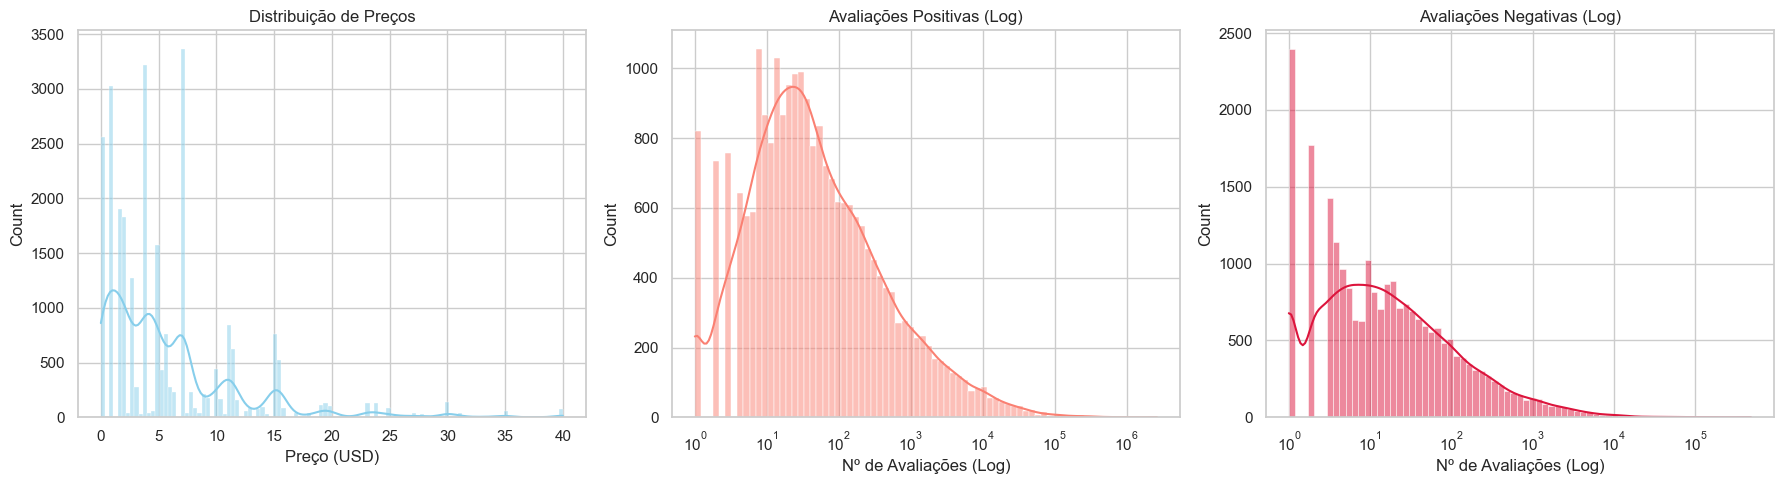

In [274]:
# =============================
#   Histogramas de avaliações
# =============================

# Criando uma cópia limpa
df_clean = df.copy()

# Converter para numérico e força erros
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')
df_clean['positive_ratings'] = pd.to_numeric(df_clean['positive_ratings'], errors='coerce')
df_clean['negative_ratings'] = pd.to_numeric(df_clean['negative_ratings'], errors='coerce')

# Remover valores negativos e limpa NaNs
df_clean = df_clean[(df_clean['price'] >= 0) & (df_clean['positive_ratings'] >= 0) & (df_clean['negative_ratings'] >= 0)]
df_clean = df_clean.dropna(subset=['price', 'positive_ratings', 'negative_ratings'])

# Garante valores maiores que 0 para log
df_plot = df_clean[(df_clean['positive_ratings'] > 0) & (df_clean['negative_ratings'] > 0)]

# Criando o painel com 3 histogramas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma 1: Preço
sns.histplot(df_clean[df_clean['price'] < 40]['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Preços')
axes[0].set_xlabel('Preço (USD)')

# Histograma 2: Avaliações Positivas
sns.histplot(df_plot['positive_ratings'], kde=True, ax=axes[1], color='salmon', log_scale=True)
axes[1].set_title('Avaliações Positivas (Log)')
axes[1].set_xlabel('Nº de Avaliações (Log)')

# Histograma 3: Avaliações Negativas
sns.histplot(df_plot['negative_ratings'], kde=True, ax=axes[2], color='crimson', log_scale=True)
axes[2].set_title('Avaliações Negativas (Log)')
axes[2].set_xlabel('Nº de Avaliações (Log)')

plt.tight_layout()
plt.show()

**Impressões dos Histogramas**

O histograma apresenta uma clara Assimetria Positiva em todos os atributos de volume. A curva de densidade (KDE) demonstra que a massa de dados está fortemente concentrada em valores baixos (poucas avaliações e preços acessíveis), com uma cauda longa em direção aos outliers. Isso prova que a Média é inflada por sucessos astronômicos (como os da Valve), enquanto a Mediana reflete a realidade da maioria: um mercado onde a maior barreira não é a rejeição (avaliações negativas), mas a invisibilidade.

### *average_playtime* e *achievements*

O atributo `average_playtime` sofre de um fenômeno onde uma enorme quantidade de jogos possui tempo de jogo próximo de zero porque são comprados em promoções (bundles) e nunca iniciados. Já o atributo achievements apresenta uma Distribuição Multimodal, com picos em números "redondos" (10, 20, 50 conquistas), indicando que os desenvolvedores seguem padrões arbitrários de design em vez de uma distribuição orgânica baseada na complexidade do jogo.

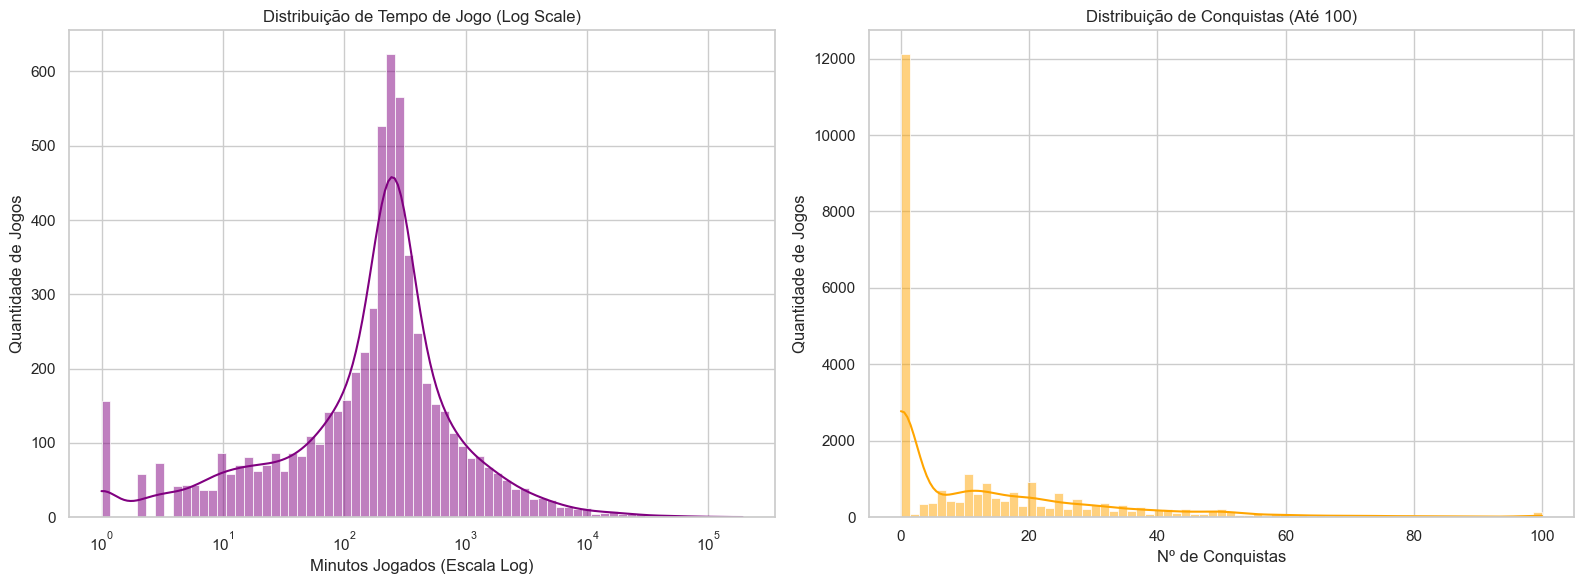

In [275]:
# =============================================================
#   Histogramas de tempo de jogo e conquistas dentro do jogo
# =============================================================

# Configurando o painel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma: Tempo Médio de Jogo (Average Playtime)
df_play = df_clean[df_clean['average_playtime'] > 0]
sns.histplot(df_play['average_playtime'], kde=True, ax=axes[0], color='purple', log_scale=True)
axes[0].set_title('Distribuição de Tempo de Jogo (Log Scale)')
axes[0].set_xlabel('Minutos Jogados (Escala Log)')
axes[0].set_ylabel('Quantidade de Jogos')

# Histograma: Quantidade de Conquistas (Achievements)
sns.histplot(df_clean[df_clean['achievements'] <= 100]['achievements'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribuição de Conquistas (Até 100)')
axes[1].set_xlabel('Nº de Conquistas')
axes[1].set_ylabel('Quantidade de Jogos')

plt.tight_layout()
plt.show()

### ❗ Impressões dos Histogramas
A alta concentração no zero em ambas as métricas reforça a tese de Saturação e Abandono. Muitos jogos são lançados sem os recursos básicos de retenção (como sistemas de conquistas bem estruturados que prendam o usuário), resultando em tempos de jogo nulos. Estatisticamente, isso gera uma curva com Curtose elevada (pico muito agudo no zero), mostrando que romper a barreira dos primeiros 10 minutos de jogo é um desafio de sobrevivência para 90% dos títulos na plataforma.

## Boxplot

Para compreender a dinâmica de sucesso e precificação na plataforma, devemos analisar como os valores se comportam além das médias globais. Esta visualização permite comparar a amplitude interquartil, a mediana e a incidência de valores extremos (outliers) em cada métrica. Através dos Boxplots, conseguimos identificar visualmente o abismo estatístico entre os títulos de nicho e os grandes blockbusters, revelando a real dispersão de preço, engajamento e retenção no ecossistema Steam.


### *price*, *positive_ratings* e *negative_ratings*


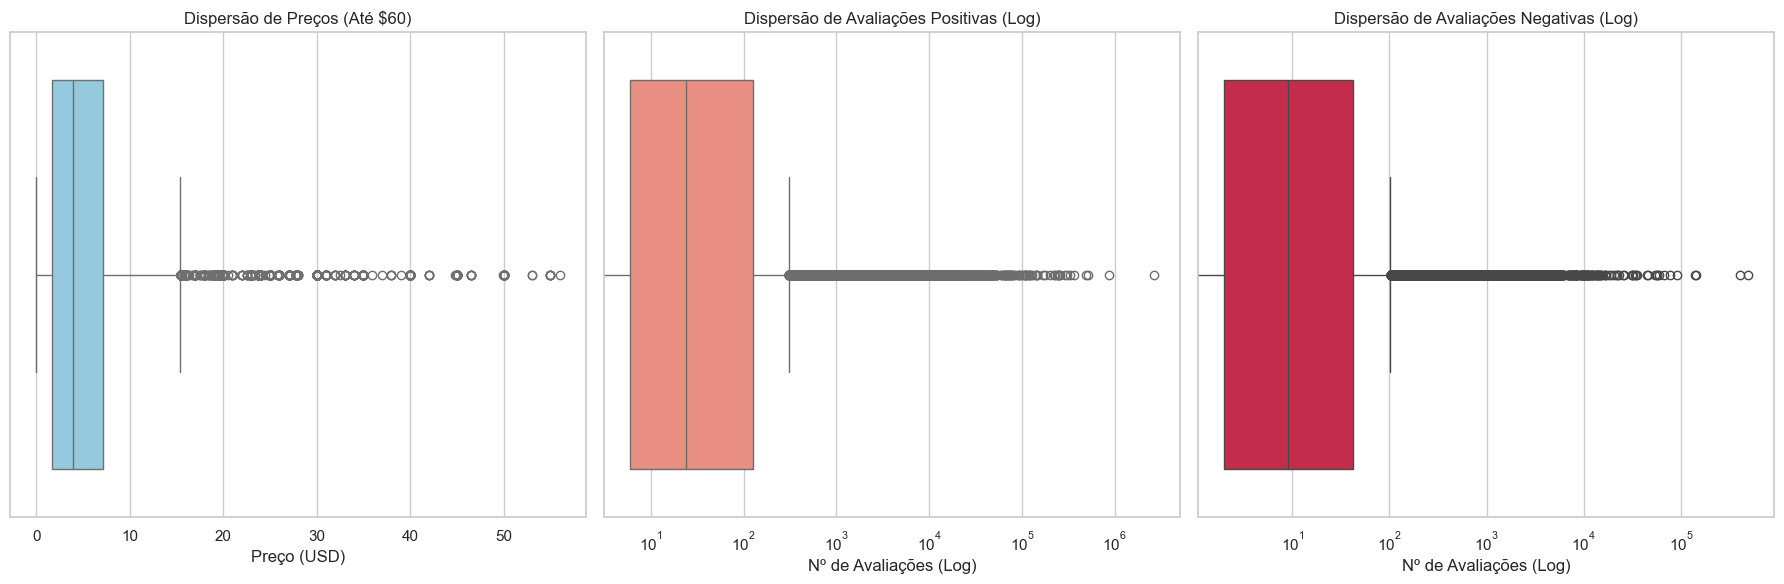

In [276]:
# =========================
#   Boxplot de avaliações
# =========================

# Criando o painel de Boxplots para Volume e Preço
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot 1: Preço
sns.boxplot(x=df_clean[df_clean['price'] <= 60]['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Dispersão de Preços (Até $60)')
axes[0].set_xlabel('Preço (USD)')

# Boxplot 2: Avaliações Positivas
sns.boxplot(x=df_clean['positive_ratings'], ax=axes[1], color='salmon')
axes[1].set_xscale('log')
axes[1].set_title('Dispersão de Avaliações Positivas (Log)')
axes[1].set_xlabel('Nº de Avaliações (Log)')

# Boxplot 3: Avaliações Negativas
sns.boxplot(x=df_clean['negative_ratings'], ax=axes[2], color='crimson')
axes[2].set_xscale('log')
axes[2].set_title('Dispersão de Avaliações Negativas (Log)')
axes[2].set_xlabel('Nº de Avaliações (Log)')

plt.tight_layout()
plt.show()

### ❗ Impressões de avaliações

A visualização confirma uma dispersão severa. A "caixa" (que contém 50% dos dados) é extremamente estreita e deslocada para a esquerda, indicando que a grande maioria dos produtos compete em uma faixa de preço e engajamento quase idêntica.
Os pontos à direita (outliers) são tão grandes que formam uma linha contínua. O fato de os boxplots de avaliações positivas e negativas serem visualmente similares reforça que o volume de feedback é, antes de tudo, um indicador de exposição.

### *average_playtime* e *achievements*

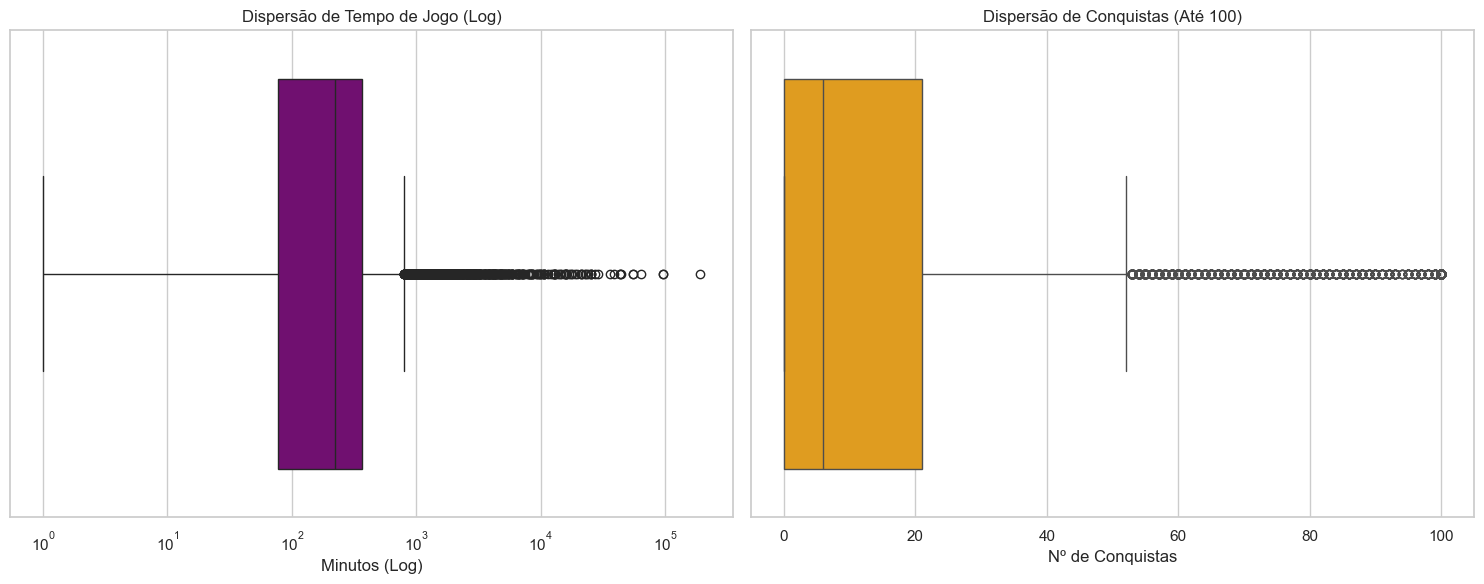

In [277]:
# ========================================================
#   Boxplot de tempo de jogo e conquistas dentro do jogo
# ========================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 4: Tempo de Jogo
sns.boxplot(x=df_clean[df_clean['average_playtime'] > 0]['average_playtime'], ax=axes[0], color='purple')
axes[0].set_xscale('log')
axes[0].set_title('Dispersão de Tempo de Jogo (Log)')
axes[0].set_xlabel('Minutos (Log)')

# Boxplot 5: Conquistas
sns.boxplot(x=df_clean[df_clean['achievements'] <= 100]['achievements'], ax=axes[1], color='orange')
axes[1].set_title('Dispersão de Conquistas (Até 100)')
axes[1].set_xlabel('Nº de Conquistas')

plt.tight_layout()
plt.show()

### ❗ Impressões tempo de jogo e conquistas

O Boxplot de Tempo de Jogo (`average_playtime`) mostra que a experiência de uso é o atributo mais desigual da plataforma, com outliers que chegam a milhares de horas, enquanto o corpo principal dos dados não passa de alguns minutos. Já o de Conquistas mostra uma amplitude interquartil ($IQR$) mais definida entre 10 e 40, indicando que este é um dos poucos atributos onde os desenvolvedores seguem uma norma de design previsível.

## Matriz de Correlação

Para entender os fatores que impulsionam o sucesso na Steam, analisamos a força da relação entre as variáveis numéricas. Esta matriz nos permite identificar se um preço mais elevado está associado a uma maior qualidade (taxa de aprovação) ou se o volume de avaliações positivas dita o engajamento de tempo dos jogadores.

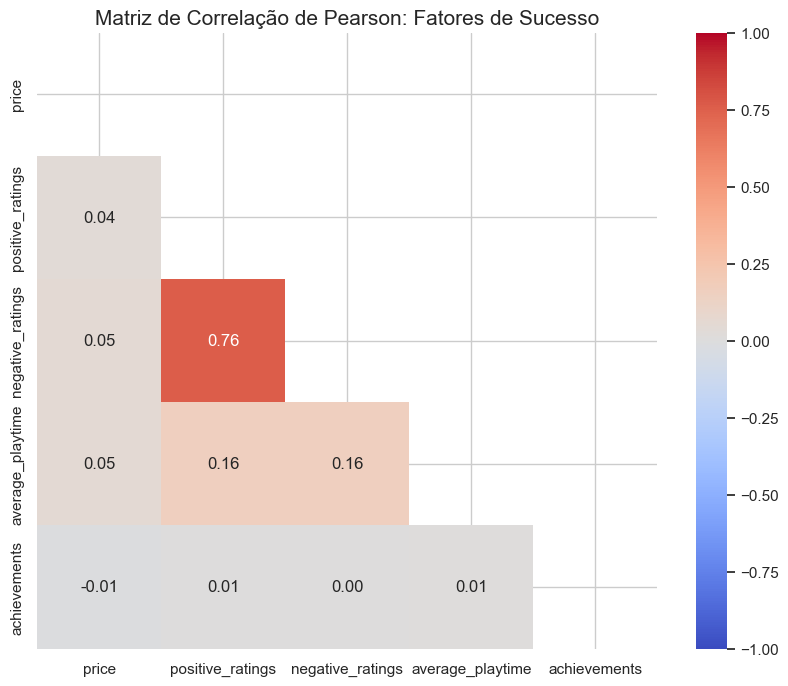

In [278]:
# ========================
#   Matriz de correlação
# ========================

# Seleciona apenas as colunas numéricas relevantes para a matriz
cols_correlacao = ['price', 'positive_ratings', 'negative_ratings', 'average_playtime', 'achievements']
corr_matrix = df_clean[cols_correlacao].corr()

# Plota o mapa de calor
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Máscara para ver apenas a metade inferior (evita repetição)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title('Matriz de Correlação de Pearson: Fatores de Sucesso', fontsize=15)
plt.show()

### ❗ Impressções da Matriz de Correlação
A matriz de Pearson ($r$) revela as seguintes dinâmicas de mercado:

- **Exposição Total ($r \approx 0.76$)**: Forte correlação entre avaliações positivas e negativas. Indica que o volume de feedback (seja bom ou ruim) é, acima de tudo, um reflexo da popularidade e alcance do jogo.
- **Independência de Preço ($r \approx 0$)**: Nenhuma correlação relevante entre preço e sucesso. Isso prova que o valor cobrado não dita o volume de vendas ou a recepção do público.
- **Engajamento Limitado**: O tempo de jogo (playtime) tem baixa correlação com as outras métricas, sugerindo que ter muitos donos não garante que o jogo será jogado por muito tempo.

## Tratamento de Valores Nulos

In [279]:
# Verificando a quantidade de nulos por coluna
nulos_por_coluna = df.isnull().sum()
print("Valores nulos encontrados:")
print(nulos_por_coluna[nulos_por_coluna > 0])

Valores nulos encontrados:
developer     1
publisher    14
dtype: int64


Optamos pela remoção das linhas incompletas pois a perda de dados é mínima se comparado com o volume total. Isso mantém a confiabilidade das estatísticas sem a necessidade de criar dados artificiais (imputação) que poderiam distorcer os perfis de desenvolvedores e categorias.

In [280]:
# Removendo apenas linhas com valores nulos nas colunas que encontramos esse tipo de situação
df = df.dropna(subset=['developer', 'publisher'])

# Verificação final
print(f"Volume de dados após a limpeza: {len(df)}")

Volume de dados após a limpeza: 27061


# Pré-Processamento de Dados e Normalização

Nesta etapa, iremos realizar a limpeza fina e a criação de novas variáveis. O objetivo é transformar colunas de texto em números e ajustar formatos para que as análises estatísticas funcionem de forma mais consistente e com melhor desempenho.

In [281]:
# ==================================
#   Criação de funções auxiliares
# ==================================

def converter_owners(intervalo):
    # Remove vírgulas e separa os limites pelo hífen
    limites = intervalo.replace(',', '').split('-')
    # Calcula a média dos intervalos
    return (int(limites[0]) + int(limites[1])) / 2

def gera_lista(df, column_name):
    # Recebe um DataFrame e o nome de uma coluna de string separada por ';' e retorna uma lista
    return df[column_name].str.split(';').apply(lambda lst: [item.strip() for item in lst])

In [282]:
# ====================================
#  Criação de métrica owners_numeric
# ====================================

# Criando a nova coluna de média de usuários
df['owners_numeric'] = df['owners'].apply(converter_owners)

# Conferência
df[['name', 'owners', 'owners_numeric']].head()

,name,owners,owners_numeric
0,Counter-Strike,10000000-20000000,15000000.00
1,Team Fortress Classic,5000000-10000000,7500000.00
2,Day of Defeat,5000000-10000000,7500000.00
3,Deathmatch Classic,5000000-10000000,7500000.00
4,Half-Life: Opposing Force,5000000-10000000,7500000.00


> **💬 Comentário:** 
> *A informação contida na coluna `owners` é um intervalo de texto (ex: *"10000-20000"*). Para calcular o faturamento, precisamos de um número único. Foi desenvolvida uma função para extrair a média deste intervalo.*

In [283]:
# ======================================
#  Criação de métrica estimated_revenue
# ======================================

# Faturamento Bruto Estimado (Preço * Média de Donos)
df['estimated_revenue'] = df['price'] * df['owners_numeric']

# Formatando para visualização rápida (em milhões)
print(f"Receita total estimada da plataforma: ${df['estimated_revenue'].sum() / 1e9:.2f} Bilhões")

Receita total estimada da plataforma: $30.86 Bilhões


> **💬 Comentário:** 
> *Obtemos a `estimated_revenue` ao cruzarmos o preço de venda `price` com a média de proprietários `owners_numeric`, transformando dados brutos de volume em um indicador financeiro. Essa coluna nos permite transitar de uma análise de popularidade para uma análise econômica, identificando quais títulos e faixas de preço realmente sustentam o faturamento da plataforma.*

> **💡 Nota:** 
> *É importante ressaltar que os cálculos de faturamento e as categorias de preço baseiam-se no valor de venda do produto no momento da extração do dataset. Muitos títulos que hoje constam como Free podem ter sido lançados como produtos pagos (ex: Team Fortress 2, CS:GO ou PUBG). Portanto, a métrica de estimated_revenue para esses casos pode estar ultrapassada.*

In [284]:
# ================================================
#  Conversão de valor release_date para datetime 
#  Criação de coluna release_year
#  Criação de coluna total_reviews
# ================================================

# Soma as colunas positive_ratings e negative_ratings
df['total_reviews'] = df['positive_ratings'] + df['negative_ratings']

# Convertendo para o formato datetime (Ano-Mês-Dia)
df['release_date'] = pd.to_datetime(df['release_date'])

# Extraindo o ano para uma coluna específica
df['release_year'] = df['release_date'].dt.year

# Conferência
df[['name', 'release_date', 'release_year', 'total_reviews']].sample(5)

,name,release_date,release_year,total_reviews
10811,Doritos VR Battle,2016-11-04,2016,16
2307,Subnautica,2018-01-23,2018,95568
17455,Liquidator,2017-10-18,2017,18
23583,Solar Fighters,2018-09-30,2018,2
20981,Tiny Mage,2018-03-20,2018,74


> **💬 Comentário:** 
> *A coluna original `release_date` é carregada como texto (string). Para realizar análises temporais e identificar tendências de lançamentos ao longo dos anos, convertemos essa coluna para o formato (datetime) e extraímos o ano em uma nova coluna.*

In [299]:
# =======================================================
#  Criação de coluna do tipo lista para a coluna genres
# =======================================================

# Cria uma coluna que gera uma lista de generos
df['genres_list'] = gera_lista(df, 'genres')

# Conferência
df[['name', 'genres_list']].sample(5)

,name,genres_list
10990,東周列萌志 Philosophic Love,"[Casual, Free to Play, Indie]"
10891,Moonlit Mayhem™,"[Action, Adventure, Indie]"
17000,"BLOCK WARRIORS: ""Open World"" Game","[Action, Adventure, Racing, RPG]"
14544,VR Sand,"[Casual, Indie, Simulation]"
1961,Shovel Knight: Treasure Trove,"[Action, Adventure, Indie]"


> **💬 Comentário:** 
> *A coluna `genres` é uma string que contém todos os gêneros cadastrados nos títulos, separados por ';'. Para trabalhar de forma mais prática, transformamos essa coluna em uma lista de gêneros, criando uma nova coluna chamada `genres_list`.*

In [ ]:
# =======================================================
#  Criação de coluna do tipo lista para a coluna categories
# =======================================================

# Cria uma coluna que gera uma lista de categorias
df['categories_list'] =  gera_lista(df, 'categories')

# Conferência
df[['name', 'categories_list']].sample(5)

,name,categories_list
12562,Psyche Soldier VR,"[Single-player, Steam Achievements, Steam Trad..."
17826,BLIK,"[Single-player, Steam Achievements, Partial Co..."
8313,Overcooked,"[Single-player, Local Multi-Player, Local Co-o..."
14288,Battle Chess,[Single-player]
10842,Raptor Valley,"[Single-player, Full controller support]"


> **💬 Comentário:** 
> *A coluna `categories` é uma string que contém todos as categorias cadastrados nos títulos, separados por ';'. Para trabalhar de forma mais prática, transformamos essa coluna em uma lista de categorias, criando uma nova coluna chamada `categories_list`.*

In [287]:
# =======================================================
#  Criação de coluna price_category
# =======================================================

# Criando intervalos de precificação
# O intervalo -1 a 0 garante a captura do valor exato 0 como 'Grátis'
bins = [-1, 0, 10, 30, df['price'].max()]
labels = ['Free', 'Budget', 'Mid-Range', 'Premium']

df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)

# Conferência
resumo_precos = df['price_category'].value_counts().reset_index()
resumo_precos.columns = ['Categoria de Preço', 'Quantidade de Títulos']
resumo_precos

,Categoria de Preço,Quantidade de Títulos
0,Budget,19584
1,Mid-Range,4598
2,Free,2556
3,Premium,323


> **💬 Comentário:** 
> *A coluna `price` contém valores contínuos que variam de **US$ 0** a centenas de dólares. Para facilitar a análise de perfis de mercado e o comportamento do consumidor, agrupamos esses valores em categorias discretas: Free, Budget, Mid-Range e Premium. Essa técnica permite segmentar o mercado e proteger nossas conclusões estatísticas contra a influência desproporcional de **outliers** de preço.*

In [288]:
# ===========================================================
#  Criação de colunas primary_developer e primary_publisher
# ===========================================================

# Mantendo apenas o primeiro desenvolvedor/publicador listado
df['primary_developer'] = df['developer'].str.split(',').str[0]
df['primary_publisher'] = df['publisher'].str.split(',').str[0]

# Conferência
df[['name', 'developer', 'primary_developer']].head()

,name,developer,primary_developer
0,Counter-Strike,Valve,Valve
1,Team Fortress Classic,Valve,Valve
2,Day of Defeat,Valve,Valve
3,Deathmatch Classic,Valve,Valve
4,Half-Life: Opposing Force,Gearbox Software,Gearbox Software


> **💬 Comentário:** 
> *Assim como na coluna de gêneros (`genres`), as colunas de `developer` e `publisher` podem conter múltiplos nomes. Para fins de agrupamento e ranking, manteremos apenas o primeiro nome listado, tratando-o como o responsável principal pelo título.*

In [289]:
# ===========================================================
#  Criação de colunas booleanas de suporte por plataforma
# ===========================================================

# Criando indicadores booleanos (True para sim, False para não)
df['win_support'] = df['platforms'].str.contains('windows')
df['mac_support'] = df['platforms'].str.contains('mac')
df['linux_support'] = df['platforms'].str.contains('linux')

# Conferência
df[['name', 'platforms', 'win_support', 'mac_support', 'linux_support']].head()

,name,platforms,win_support,mac_support,linux_support
0,Counter-Strike,windows;mac;linux,True,True,True
1,Team Fortress Classic,windows;mac;linux,True,True,True
2,Day of Defeat,windows;mac;linux,True,True,True
3,Deathmatch Classic,windows;mac;linux,True,True,True
4,Half-Life: Opposing Force,windows;mac;linux,True,True,True


> **💬 Comentário:** 
> *A coluna `platforms` indica a compatibilidade do jogo. Criamos indicadores booleanos para Windows, Mac e Linux, permitindo analisar qual a porcentagem da biblioteca Steam é acessível para usuários de sistemas operacionais alternativos.*

In [290]:
# ============================================================================
#  Criação indicadores booleano para jogos que tenham suporte a Multiplayer
# ============================================================================

# Criando indicadores booleano
df['is_multiplayer'] = df['categories_list'].apply(
    lambda x: True if any(item in ['Multi-player', 'Online Multi-Player', 'Local Multi-Player'] for item in x) else False
)

# Conferência
df[['name', 'is_multiplayer']].sample(5)

,name,is_multiplayer
5584,Through the Woods,False
7266,The Odyssey: Winds of Athena,False
24004,Crazy Alchemist,False
11974,The First Tree,False
3915,Moto Racer Collection,False


> **💬 Comentário:** 
> *A coluna `categories` indica as funcionalidades do jogo. Criamos um indicador booleano para identificar se o título oferece suporte a Multiplayer, permitindo validar se o efeito de rede impacta no volume de proprietários.*

In [ ]:
# =================================================
#  Criação de Métrica rating_ratio e total_ratings
# =================================================

# Soma positive_ratings e negative_ratings
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']

# Cálcula da Taxa de Aprovação em %
df['rating_ratio'] = (df['positive_ratings'] / df['total_ratings']) * 100
df['rating_ratio'] = df['rating_ratio'].fillna(0)

# Conferência
df[['name', 'positive_ratings', 'total_ratings', 'rating_ratio']].head()

,name,positive_ratings,total_ratings,rating_ratio
0,Counter-Strike,124534,127873,97.39
1,Team Fortress Classic,3318,3951,83.98
2,Day of Defeat,3416,3814,89.56
3,Deathmatch Classic,1273,1540,82.66
4,Half-Life: Opposing Force,5250,5538,94.80


> **💬 Comentário:** 
> *Para validar as hipóteses de **Qualidade** vs. **Preço** e **Maturação**, criamos duas métricas fundamentais: `total_ratings`, que consolida o volume absoluto de interações, e `rating_ratio`, que extrai a porcentagem de aprovação. Esta última é uma métrica que nos permite comparar a satisfação do usuário entre jogos de diferentes escalas, independentemente do volume total de vendas.*

In [ ]:
# ===========================
#  Resumo geral das colunas
# ===========================

# Verificando as dimensões finais
print(f"Dimensões finais: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print("-" * 50)
print(df.info())

# Amostra aleatória das novas colunas
df.sample(5)[['release_year', 'owners_numeric', 'total_reviews', 'estimated_revenue', 'genres_list','categories_list',
'is_multiplayer',  'price_category', 'linux_support', 'total_ratings', 'rating_ratio']]

Dimensões finais: 27061 linhas e 33 colunas.
--------------------------------------------------
<class 'pandas.DataFrame'>
Index: 27061 entries, 0 to 27074
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   appid              27061 non-null  int64         
 1   name               27061 non-null  str           
 2   release_date       27061 non-null  datetime64[us]
 3   english            27061 non-null  int64         
 4   developer          27061 non-null  str           
 5   publisher          27061 non-null  str           
 6   platforms          27061 non-null  str           
 7   required_age       27061 non-null  int64         
 8   categories         27061 non-null  str           
 9   genres             27061 non-null  str           
 10  steamspy_tags      27061 non-null  str           
 11  achievements       27061 non-null  int64         
 12  positive_ratings   27061 non-null  i

,release_year,owners_numeric,total_reviews,estimated_revenue,genres_list,categories_list,is_multiplayer,price_category,linux_support,total_ratings,rating_ratio
15553,2018,10000.00,13,113900.00,[Simulation],[Single-player],False,Mid-Range,False,13,69.23
2759,2014,150000.00,894,1048500.00,"[Adventure, Casual]","[Single-player, Steam Achievements, Steam Trad...",False,Budget,True,894,97.54
18637,2018,10000.00,11,71900.00,"[Indie, Simulation, Sports]","[Single-player, Multi-player, Online Multi-Pla...",True,Budget,False,11,90.91
14893,2017,10000.00,17,7900.00,"[Action, Adventure, Casual, Indie, Strategy]","[Single-player, Steam Achievements]",False,Budget,False,17,58.82
17081,2017,10000.00,97,59900.00,"[Casual, Indie]","[Single-player, Steam Achievements, Full contr...",False,Budget,False,97,90.72


# Respondendo nossas hipóteses

## Hipótese 1

Existe uma correlação positiva entre o preço do título e sua taxa de aprovação, sugerindo que o investimento se traduz em qualidade percebida?

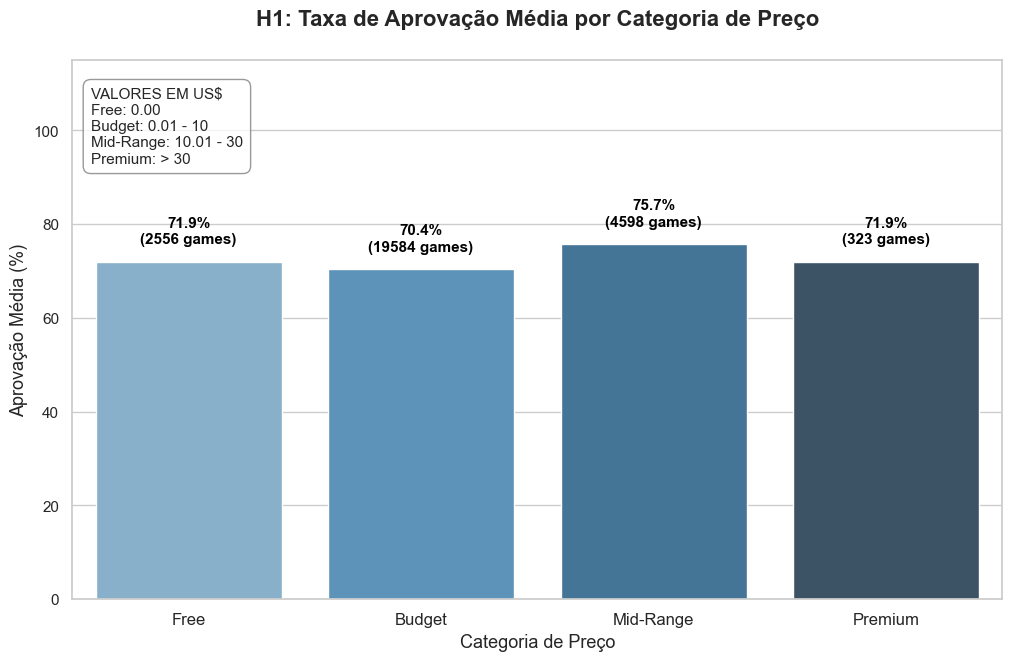

In [293]:
# =================================
#  Gráfico de barras - Hipótese 1
# =================================

# Definição da ordem lógica
category_order = ['Free', 'Budget', 'Mid-Range', 'Premium']

# Preparação dos dados
h1_data = df.groupby('price_category', observed=True)['rating_ratio'].mean().reindex(category_order)
category_counts = df['price_category'].value_counts()

# Texto do Sumário de Valores
summary_text = (
    "VALORES EM US$\n"
    "Free: 0.00\n"
    "Budget: 0.01 - 10\n"
    "Mid-Range: 10.01 - 30\n"
    "Premium: > 30"
)

# Configuração visual
plt.figure(figsize=(12, 7))

# Plotagem
ax = sns.barplot(
    x=h1_data.index, 
    y=h1_data.values, 
    order=category_order,
    hue=h1_data.index, 
    palette='Blues_d', 
    legend=False
)

# Adicionando o Quadro como Sumário (TextBox)
plt.text(0.02, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', 
         facecolor='white', alpha=0.8, edgecolor='gray'))

# Estilização de títulos e eixos
plt.title('H1: Taxa de Aprovação Média por Categoria de Preço', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Aprovação Média (%)', fontsize=13)
plt.xlabel('Categoria de Preço', fontsize=13)
plt.ylim(0, 115)

# Centralização dos nomes no eixo X (mais limpos agora)
plt.xticks(ticks=range(len(category_order)), labels=category_order, fontsize=12)

# dicionando rótulos sobre as barras
for i, p in enumerate(ax.patches):
    cat_name = category_order[i]
    count = category_counts[cat_name]
    height = p.get_height()
    
    ax.annotate(f'{height:.1f}%\n({count} games)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 22), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold', color='black')
plt.show()

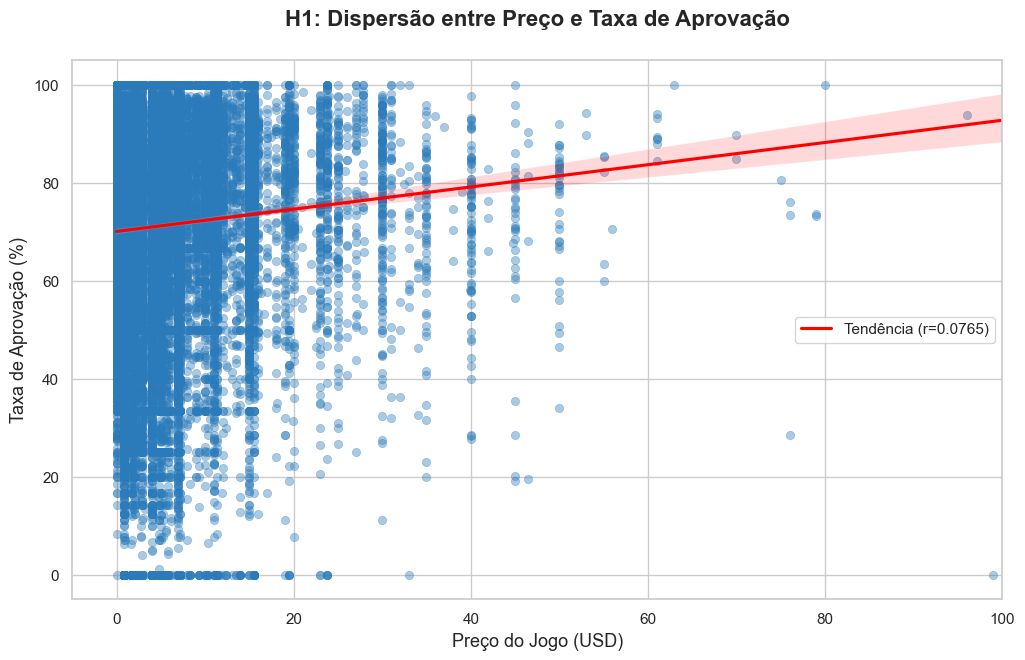

In [294]:
# ===========================================================
#  Análise de Dispersão - Hipótese 1
# ===========================================================

plt.figure(figsize=(12, 7))

# Cálculo da linha de correlação
correlation_h1 = df['price'].corr(df['rating_ratio'])

# Plotagem de dispersão
sns.scatterplot(
    data=df, 
    x='price', 
    y='rating_ratio', 
    alpha=0.4, 
    color='#2b7bba',
    edgecolor=None
)

# Adição da linha de tendência
sns.regplot(
    data=df, 
    x='price', 
    y='rating_ratio', 
    scatter=False, 
    color='red', 
    label=f"Tendência (r={correlation_h1:.4f})"
)

# Layout
plt.title('H1: Dispersão entre Preço e Taxa de Aprovação', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Taxa de Aprovação (%)', fontsize=13)
plt.xlabel('Preço do Jogo (USD)', fontsize=13)
plt.legend()
plt.xlim(-5, 100) 
plt.ylim(-5, 105)

plt.show()

### Resposta Hipótese 1:
*Nossa primeira hipótese foi refutada. Os dados revelam que o preço não é um indicador de qualidade na plataforma Steam, apresentando uma correlação insignificante de **0,0765**. Isso desconstrói a ideia de que jogos mais caros garantem maior satisfação, provando que títulos de todos os valores ocupam as mesmas faixas de aprovação. Mesmo após a remoção de outliers, a tendência se manteve: a plataforma funciona como um mercado democrático onde a experiência de jogo prevalece sobre o valor sugerido, nivelando desenvolvedores independentes e grandes estúdios sob o mesmo critério de avaliação pública dos usuários.*

## Hipótese 2
Gêneros com menor volume de títulos apresentam densidade de avaliações positivas superior a gêneros saturados?

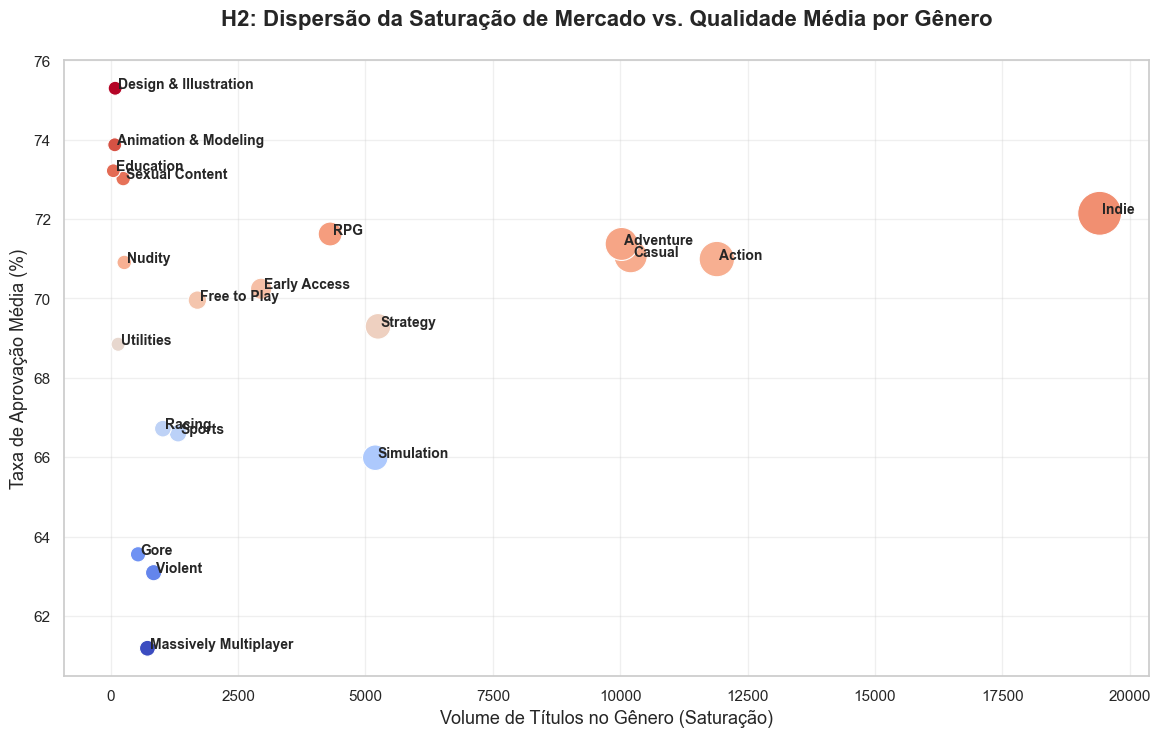

In [295]:
# ====================================
#  Análise de Dispersão - Hipótese 2
# ====================================

# Criando o DataFrame explodido
df_genres_exploded = df.explode('genres_list')

# Agrupando por gênero
genre_summary = df_genres_exploded.groupby('genres_list').agg(
    total_games=('name', 'count'),
    avg_rating=('rating_ratio', 'mean')
).query('total_games > 50').sort_values(by='total_games', ascending=False)


plt.figure(figsize=(14, 8))

# Plotagem de dispersão
ax = sns.scatterplot(
    data=genre_summary, 
    x='total_games', 
    y='avg_rating', 
    size='total_games', 
    hue='avg_rating', 
    palette='coolwarm', 
    sizes=(100, 1000),
    legend=False
)

# Adição dos nomes dos gêneros
for i in range(genre_summary.shape[0]):
    plt.text(
        genre_summary.total_games.iloc[i] + 50, 
        genre_summary.avg_rating.iloc[i], 
        genre_summary.index[i], 
        fontsize=10, fontweight='bold'
    )

# Layout
plt.title('H2: Dispersão da Saturação de Mercado vs. Qualidade Média por Gênero', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Volume de Títulos no Gênero (Saturação)', fontsize=13)
plt.ylabel('Taxa de Aprovação Média (%)', fontsize=13)
plt.grid(True, alpha=0.3)

plt.show()

### Resposta Hipótese 2:

*A Hipótese 2 é válida, revelando que o mercado saturado atua como um diminuidor de qualidade. Ao observarmos o extremo direito do gráfico, onde residem gêneros como Indie, Action e Casual, vemos que o volume massivo de títulos empurra a aprovação média para patamares mais baixos. Isso ocorre devido à baixa barreira de entrada, que inunda o mercado com jogos menos polidos, gerando um ruído que prejudica a percepção geral do gênero.*

*Em contrapartida, a "Zona de Prestígio" do gráfico situa-se no quadrante superior esquerdo e central. Gêneros como Estratégia, Simulação e RPG mostram que, ao fugir da saturação extrema, os desenvolvedores encontram públicos mais nichados, porém muito mais satisfeitos. O gráfico prova que o sucesso crítico não está na popularidade de massa, mas no equilíbrio: gêneros com volume moderado permitem que títulos de qualidade se destaquem sem serem sufocados pela oferta excessiva. Portanto, o "nicho" não é apenas uma questão de ter menos jogos, mas de oferecer experiências especializadas para comunidades fiéis, resultando em uma recepção significativamente superior à dos gêneros saturados.*

> **💡 Nota:** 
> *Ao interpretarmos a saturação do gênero Indie (o ponto mais extremo à direita do nosso gráfico), é vital compreender que ele opera como uma subcategoria. Diferente de Estratégia ou Corrida, que definem mecânicas específicas, o selo Indie agrupa títulos de estúdios independentes que obrigatoriamente possuem um segundo ou terceiro gênero imbuído (como **Indie-Action** ou **Indie-Horror**).*

## Hipótese 3
A presença de funcionalidades e modos de jogo 'Multiplayer' está associada a um volume significativamente maior de reviews e estimativa de proprietários?

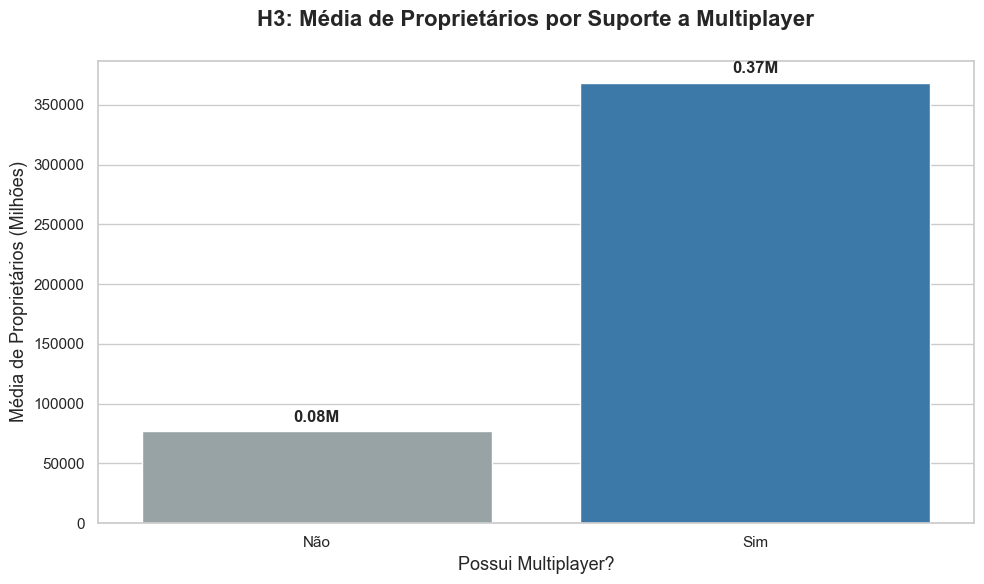

In [296]:
# =================================
#  Gráfico de barras - Hipótese 3
# =================================

# Agrupa por volume de proprietário
multi_vs_single = df.groupby('is_multiplayer')['owners_numeric'].mean().sort_values()

# Configuração visual
plt.figure(figsize=(10, 6))

# Altera valores booleanos para Sim e Não
multi_vs_single.index = multi_vs_single.index.map({True: 'Sim', False: 'Não'})

# Plotagem do gráfico de barras
ax = sns.barplot(
    x=multi_vs_single.index, 
    y=multi_vs_single.values, 
    hue=multi_vs_single.index,
    palette={'Sim': '#2b7bba', 'Não': '#95a5a6'},
    legend=False
)

# Estilização de títulos e eixos
plt.title('H3: Média de Proprietários por Suporte a Multiplayer', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Média de Proprietários (Milhões)', fontsize=13)
plt.xlabel('Possui Multiplayer?', fontsize=13)

# Adicionando rótulos de dados
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height/1e6:.2f}M', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points', 
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Resposta Hipótese 3:

*A análise do gráfico acima revela que o suporte ao Multiplayer não é apenas um recurso adicional, mas um dos maiores catalisadores de alcance de mercado na Steam. Enquanto títulos estritamente `Single-player` sustentam uma base média de **80 mil** usuários, a introdução de funcionalidades multi-jogador eleva esse patamar para um pouco mais que **350 mil** usuários — um salto impressionante de 500% no volume médio de proprietários por jogo.*

*Diferente de uma experiência solitária, que possui um ciclo de vida linear, o jogo multiplayer transforma cada novo proprietário em um potencial promotor da marca, incentivando amigos a adquirirem o título para jogarem juntos. Os números comprovam que se o objetivo de um projeto é escala e penetração de mercado, a conectividade social é o motor mais potente para romper a barreira do nicho e atingir as massas.*

## Hipótese 4
Jogos com maior tempo de mercado acumulam um volume maior de avaliações, funcionando como prova social para novos usuários?

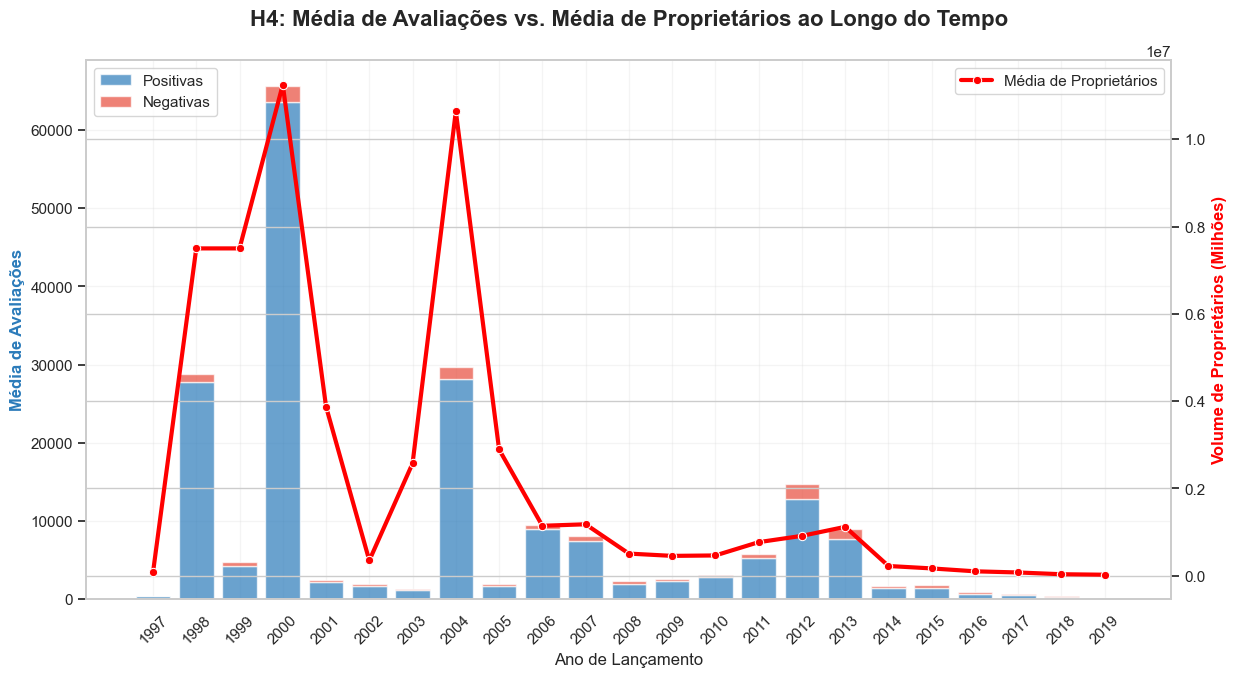

In [297]:
# ===========================================================
#  Gráfico de barras e linha - Hipótese 4
# ===========================================================

# Agrupa dados por ano
group_data = df.groupby('release_year').agg({
    'positive_ratings': 'mean',
    'negative_ratings': 'mean',
    'total_reviews': 'mean',
    'owners_numeric': 'mean'
}).reset_index()

# Configuração visual
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotagem das barras empilhadas
ax1.bar(group_data['release_year'].astype(str), group_data['positive_ratings'], 
        label='Positivas', color='#2b7bba', alpha=0.7)

ax1.bar(group_data['release_year'].astype(str), group_data['negative_ratings'], 
        bottom=group_data['positive_ratings'],
        label='Negativas', color='#e74c3c', alpha=0.7)

ax1.set_ylabel('Média de Avaliações', fontsize=12, color='#2b7bba', fontweight='bold')
ax1.set_xlabel('Ano de Lançamento', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')

# Cria a linha média de proprietários e eixo secundario
ax2 = ax1.twinx()
sns.lineplot(
    data=group_data, 
    x=range(len(group_data)),
    y='owners_numeric', 
    ax=ax2, 
    color='red', 
    marker='o', 
    linewidth=3, 
    label='Média de Proprietários'
)
ax2.set_ylabel('Volume de Proprietários (Milhões)', fontsize=12, color='red', fontweight='bold')
ax2.legend(loc='upper right')

# Adiciona título
plt.title('H4: Média de Avaliações vs. Média de Proprietários ao Longo do Tempo', fontsize=16, fontweight='bold', pad=25)
ax1.grid(True, alpha=0.2)

plt.show()

### Resposta Hipótese 4:
*Observando o gráfico vemos que as barras (média de avaliações) e a linha vermelha (média de proprietários) caminham em conjunto ao passar dos anos. Isso prova que o usuário numérico (`owner_numeric`) não é um dado isolado; ele é atraído e retido pela prova social acumulada. Quanto mais avaliações um jogo possui, maior é a sua credibilidade, o que facilita a conversão de novos compradores e entrantes ao longo dos anos.*

*Através do gráfico confirmamos que a longevidade é um ativo estratégico. O tempo na plataforma atua como um filtro de qualidade e confiança: jogos que permanecem relevantes acumulam um maior número de avaliações que serve como garantia para futuras gerações de usuários. Para um desenvolvedor, o gráfico ensina que o lançamento é apenas o começo; o verdadeiro sucesso de escala (a linha vermelha alta) é construído através da persistência e da manutenção da prova social ao longo dos anos.*

# Conclusão

*Através do tratamento de dados complexos, como a explosão de listas de gêneros e categorias e o cálculo do ponto médio de proprietários, foi possível transformar dados brutos em insights estratégicos. A análise exploratória revelou que, embora o mercado seja inundado por milhares de títulos (especialmente no segmento **Indie**), existem padrões claros que distinguem sucessos de massa de nichos de alta qualidade. O uso de visualizações combinadas de dispersão, barras empilhadas e eixos duplos permitiu identificar correlações que muitas vezes passam despercebidas por desenvolvedores iniciantes.*

*As quatro hipóteses levantadas foram validadas e trazem algumas conclusões:*

1. *Existe uma correlação direta entre o preço do jogo e a sua taxa de aprovação? Não. A Hipótese 1 foi refutada. A correlação próxima de zero ($r = 0.07$) prova que o preço não é um indicador de qualidade; jogos gratuitos ou de baixo custo podem ser tão bem avaliados quanto títulos premium.*

2. *Gêneros de nicho possuem notas médias superiores aos gêneros saturados? Sim. A Hipótese 2 foi confirmada. Gêneros com menor volume de títulos e barreiras técnicas maiores, como Estratégia e Simulação, mantêm médias de aprovação superiores à de gêneros massivamente saturados como Indie e Ação.*

3. *O suporte ao Multiplayer impulsiona o volume de usuários através do efeito de rede? Sim. A Hipótese 3 foi confirmada. Jogos com funcionalidades multiplayer possuem um alcance de mercado mais de 4,5 vezes superior aos jogos Single-player, atingindo uma média de 370 mil usuários contra apenas 80 mil dos jogos solitários.*

4. *Jogos com maior tempo de mercado acumulam um volume maior de avaliações, funcionando como prova social? Sim. A Hipótese 4 foi confirmada. O tempo de mercado atua como um acumulador de autoridade. Títulos mais antigos possuem picos drásticos de avaliações e usuários, provando que a longevidade na plataforma constrói uma "prova social" que serve como selo de garantia para novos compradores.*

*Esta análise demonstra que para um jogo prosperar na Steam, a qualidade percebida e a conectividade entre jogadores (Multiplayer) são motores de crescimento muito mais potentes do que o valor da etiqueta (Preço), e que a persistência ao longo dos anos (Maturação) é o que consolida o título como um sucesso financeiro e de crítica.*